<a href="https://colab.research.google.com/github/flatironinstitute/2026-flatiron-cmb-summer-school/blob/main/notebooks/CMB_School_Lensing_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lensing reconstruction tutorial

This notebook, featured in the 2026 Flatiron Institute CMB Summer School, is based on 
https://github.com/jeffmcm1977/CMBAnalysis_SummerSchool (credits: Jeff McMahon, Renee Hlozek, Sigurd Naess), with further revisions and contributions by Alex van Engelen, Alexandra Rahlin, Mathew Madhavacheril, Joshua Kim, Zach Atkins, Will Coulton, Melanie Archipley, Tom Crawford.

In [28]:
!python -c "import cmb_modules" || ( \
    wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/cmb_modules.py \
    wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/lens_modules.py \
    wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/constants.py \
    wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/CMB_fiducial_totalCls.dat \
    wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/CAMB_fiducial_cosmo_scalCls_for_lensing.dat \
)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
# We use some stuff we learned before
import cmb_modules as cm
import lens_modules as lm
np.random.seed(100)

In this tutorial, we will learn how to obtain the underlying lensing convergence (the projected matter density) from an observed map of the CMB. 

We will first simulate a lensed CMB map as we learnt in an earlier tutorial

In [30]:
patch_deg_width = 40. # patch width in degrees
pix_size = 1.5 # pixel size in arcminutes
ells,ucltt,lcltt,clkk = lm.get_theory()
N,lensed,kappa,ly,lx,modlmap = lm.get_lensed(patch_deg_width,pix_size,ells,ucltt,clkk)

Let us now convolve this map with a beam and add noise

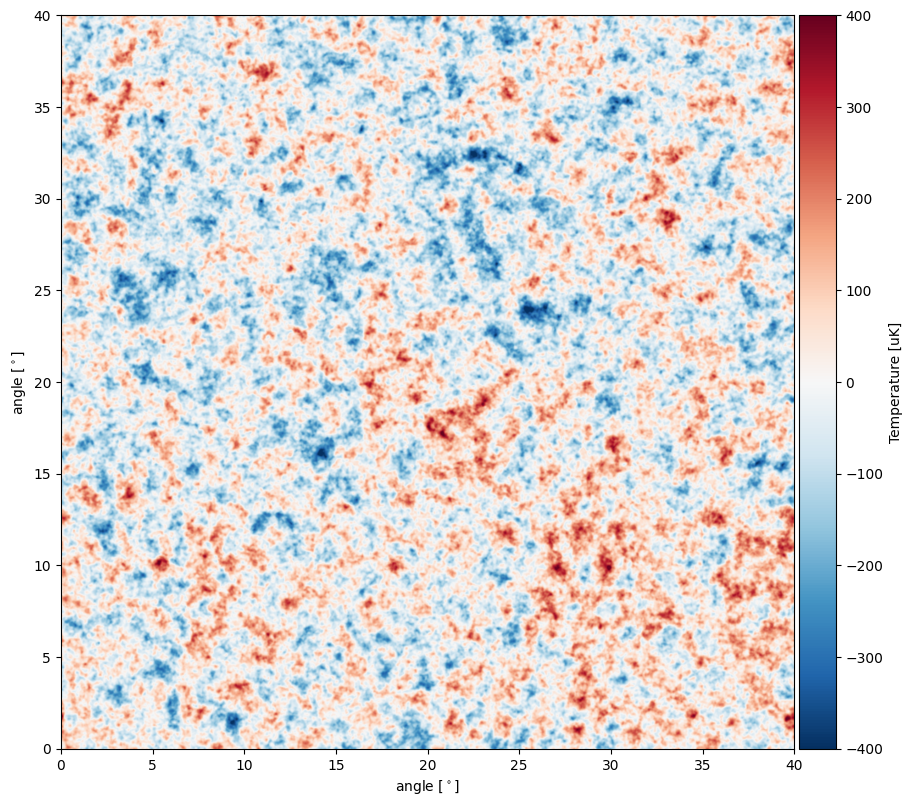

In [31]:
# Beam
beam_arcmin = 1.4
def gauss_beam(ell,fwhm):
    # A gaussian beam transfer function (map-space, i.e. one power)
    tht_fwhm = np.deg2rad(fwhm / 60.)
    return np.exp(-(tht_fwhm**2.)*(ell**2.) / (16.*np.log(2.)))
# Evaluate the beam on an isotropic Fourier grid
kbeam2d = gauss_beam(modlmap,beam_arcmin)
# Filter the map to convolve it with a beam
beamed = lm.filter_map(lensed,kbeam2d)

# Noise
noise_uk_arcmin = 3. 
# White noise
Clnoise = (noise_uk_arcmin*np.pi/180./60.)**2.
Dlnoise = Clnoise*ells*(ells+1.)/2./np.pi
# Make a GRF noise map
noise_map = cm.make_CMB_T_map(N,pix_size,ells,Dlnoise)

# The observed map
observed = beamed + noise_map

plt.title("simulated CMB map with lensing")
cm.Plot_CMB_Map(observed,-400,400,patch_deg_width,patch_deg_width)

# Lensing reconstruction

Let's expand the lens equation

<!-- $\newcommand{\al}{\boldsymbol{\alpha}}$
$\newcommand{\textbf{x}}{\textbf{x}}$
$\newcommand{\nab}{\boldsymbol{\nabla}}$
$\newcommand{\uT}{{\tilde{T}}}$
$\newcommand{\tilde{C}}{{\tilde{C}}}$
$\newcommand{\dphi}{{\nab\phi}}$
$\newcommand{\O}{{\mathcal{O}}}$
$\newcommand{\boldsymbol{\ell}}{{\boldsymbol{\ell}}}$
$\newcommand{\textbf{L}}{{\textbf{L}}}$ -->
$$T(\textbf{x}) = \tilde{T}(\textbf{x}+\boldsymbol{\alpha})$$

in a Taylor series (and substitute $\boldsymbol{\alpha}={\boldsymbol{\nabla}\phi}$) in the weak-lensing limit of small $\phi$,

$
T(\textbf{x}) \approx \tilde{T}(\textbf{x}) + \nabla \tilde{T} \cdot {\boldsymbol{\nabla}\phi} + \mathcal{O}({\boldsymbol{\nabla}\phi}^2)
$ 

Homework exercise: Using 2d Fourier transforms,

$
X(\boldsymbol{\ell}) = \int d^2\textbf{x} ~e^{-i\boldsymbol{\ell}\cdot\textbf{x}}X(\textbf{x})
$
$
X(\textbf{x}) = \int \frac{d^2\boldsymbol{\ell}}{(2\pi)^2} ~e^{i\boldsymbol{\ell}\cdot\textbf{x}}X(\boldsymbol{\ell})
$
$
\int d^2\textbf{x} e^{i\boldsymbol{\ell}\cdot\textbf{x}} = (2\pi)^2 \delta(\boldsymbol{\ell})
$

show that to leading order in the lensing potential, lensing induces coupling between modes of the CMB map:


$
\langle T(\boldsymbol{\ell}_1)T(\boldsymbol{\ell}_2) \rangle_{\rm CMB} = \phi(\textbf{L})\left[\tilde{C}^{TT}_{\ell_1}(\textbf{L} \cdot \boldsymbol{\ell}_1) + \tilde{C}^{TT}_{\ell_2}(\textbf{L} \cdot \boldsymbol{\ell}_2)\right]
$

where the averaging is over realizations of the unlensed CMB field $\tilde{T}$.  Note: $L = \ell_2 - \ell_1$ represents the multiplole moment of the lensing reconstruciton.  

The correlations present in the above result motivates extracting modes of the lensing potential $\phi(\textbf{L})$ by taking a weighted average of products of CMB modes. The weights can be derived such that the noise in the reconstruction is minimized. The resulting estimator is:

$$
\hat{\kappa}(\textbf{L}) = -A(\textbf{L}) \int d^2\boldsymbol{\ell}_1 \left[\tilde{C}^{TT}_{\ell_1}(\textbf{L} \cdot \boldsymbol{\ell}_1) + \tilde{C}^{TT}_{\ell_2}(\textbf{L} \cdot \boldsymbol{\ell}_2)\right]\frac{T(\boldsymbol{\ell}_1)T(\boldsymbol{\ell}_2)}{C^{TT}_{\ell_1}C^{TT}_{\ell_2}}
$$

Homework exercise: Show that the above estimator can be written as a real-space multiplication

$$
\hat{\kappa} \propto -\nabla \cdot \left[\left(\nabla T_W\right) T_H \right]
$$

where $T_W$ is the temperature map Wiener filtered by $\frac{\tilde{C}^{TT}_{\ell}}{C^{TT}_{\ell}}$ and $T_H$ is the temperature map inverse variance filtered by $\frac{1}{C^{TT}_{\ell}}$.

In what follows we use this real space expression to recontruct an estimate for the lensing map and explore some of the issues that must be taclked to extraxt science from these maps.   

We refer you to the classic paper by [Hu and Okamoto](https://arxiv.org/pdf/astro-ph/0111606), and to a recent paper [Maniyar et al](https://arxiv.org/pdf/2101.12193) for more details of these quadratic estimators.  Maximum Liklihood techniques for lensign reconstruciton are know to produce higher signal to noise for the same experiment.  These are beyond the scope of this notebook.  If you are interested in details we recomend the classic paper by [Hirata and Seljak](https://arxiv.org/pdf/astro-ph/0209489) and the more recent paper by [Carron et al](https://arxiv.org/abs/1704.08230)

### <font color='red'>EXERCISE: </font> 
Code up the real space estimate given above to complete the lensing estimator that has been started for you below.


map mean: 8.149072527885437e-14 map rms: 99687.36671779348


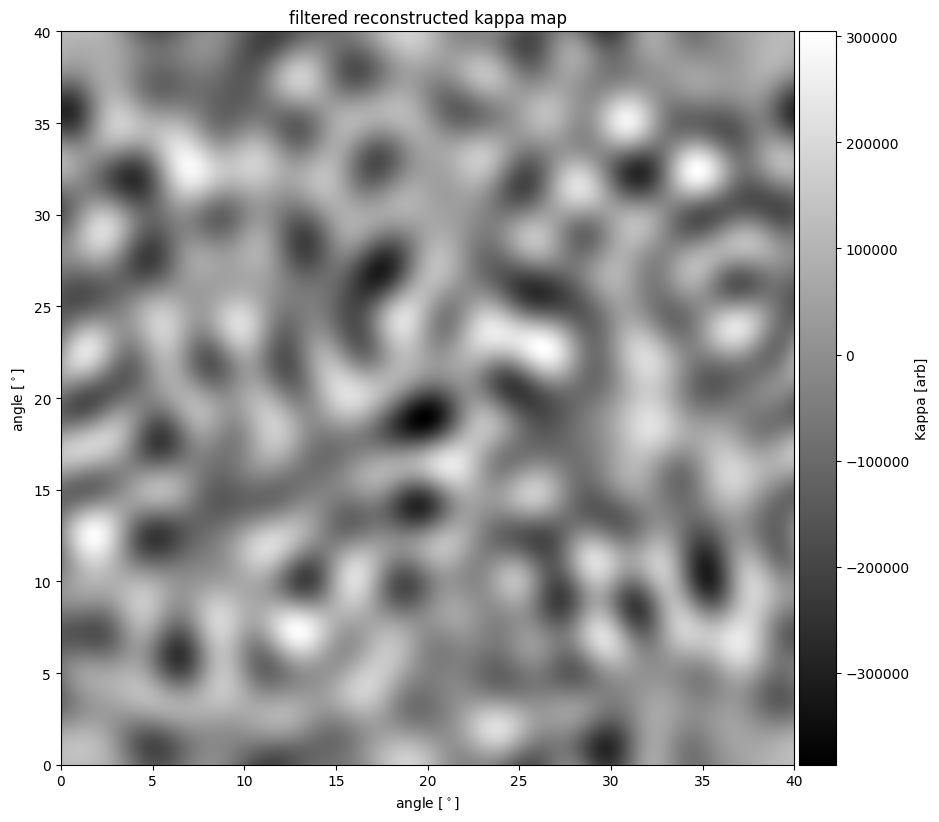

map mean: -1.824929096727601e-19 map rms: 0.010591063652515383


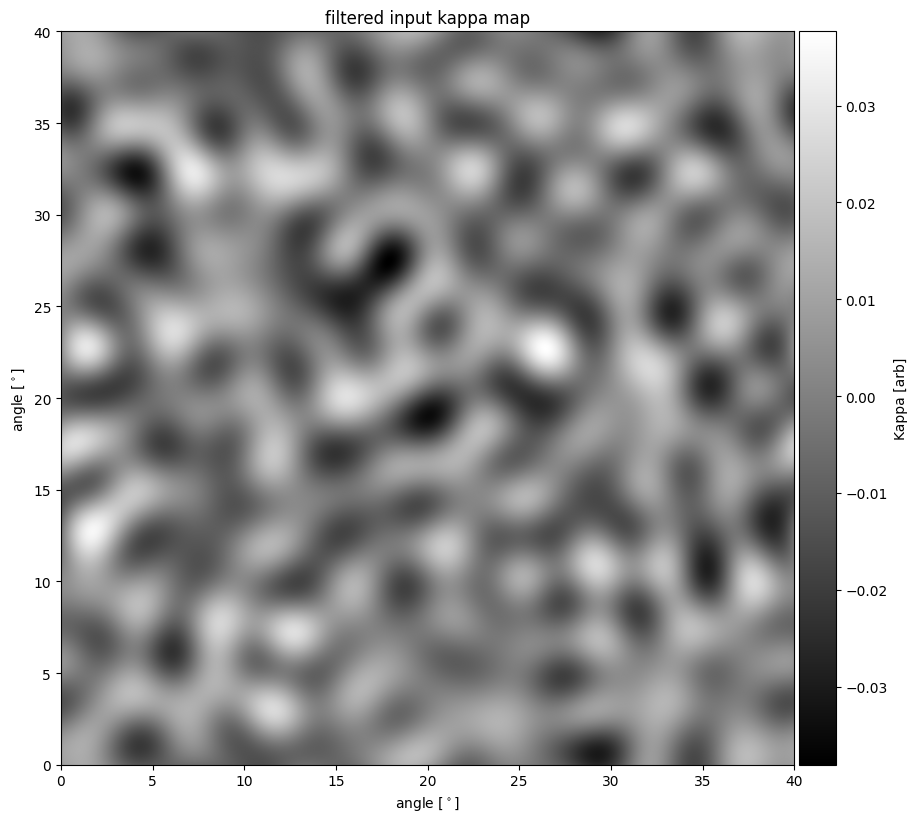

In [32]:
# Now we attempt to reconstruct a lensing map from the observed map
def qe_reconstruct(tmap,unlensed_cmb_power_2d,total_cmb_power_2d,ellmin,ellmax,modlmap,ly,lx):
    """
    The simplest form of the quadratic estimator is

    kappa_recon = - div ( grad(T) T )
    where grad(T) is Wiener filtered with (unlensed_cmb_power/total_cmb_power)
    and T is filtered with (1/toGtal_cmb_power)
    where the T map is beam deconvolved and
    where total_cmb_power = lensed_cmb_power + noise_power / beam^2

    The reconstruction is limited to ellmin < ells < ellmax of the CMB temperature map.

    The grad and div operations require knowledge of:
    modlmap: absolute wavenumbers of Fourier pixels
    ly: map of ly Fourier coordinate of each pixel
    lx: map of lx Fourier coordinate of each pixel
    (note modlmap = sqrt(ly**2 + lx**2)
    """
    inv_noise_filter = lm.kmask((1./total_cmb_power_2d),modlmap,ellmin,ellmax)
    grad_filter = lm.kmask((unlensed_cmb_power_2d/total_cmb_power_2d),modlmap,ellmin,ellmax)

    gradTy,gradTx = lm.gradient(tmap,ly,lx)

    # The Wiener filtered gradient Grad(T_G)
    filtered_gradTy = lm.filter_map(gradTy,grad_filter)
    filtered_gradTx = lm.filter_map(gradTx,grad_filter)
    # The inverse variance filtered T_H
    filtered_T = lm.filter_map(tmap,inv_noise_filter)
    
    ############## COMPLETE THIS!!!
    # ADD A LINE BELOW TO GET ukappa = divergence(Grad(T_G) * T_H)
    tmp_x = filtered_gradTx * filtered_T
    tmp_y = filtered_gradTy * filtered_T
    ukappa = div(tmp_y, tmp_x, ly, lx)
    ############## COMPLETE THIS!!!
    
    # We filter with 1/L^2 at the end to make the normalization white
    return -lm.filter_map(ukappa,lm.kmask(1/modlmap**2,modlmap,ellmin=2))

# For this we also need to know how to calculate a divergence
def div(imapy,imapx,ly,lx):
    # Return divergence grad(Y)_y + grad(X)_x
    ############## COMPLETE THIS!!!
    divergence = lm.gradient(imapy,ly,lx)[0] + lm.gradient(imapx,ly,lx)[1]
    # COMPLETE THIS FUNCTION THAT RETURNS THE DIVERGENCE
    ############## COMPLETE THIS!!!
    return divergence


def interp(x,y,bounds_error=False,fill_value=0.,**kwargs):
    # Just a simple interpolator that fills with zeros by default
    from scipy.interpolate import interp1d
    return interp1d(x,y,bounds_error=bounds_error,fill_value=fill_value,**kwargs)


# To use this we need unlensed and total spectra interpolated on to the 2D Fourier grid
### Prepare 2D Fourier space interpolations of theory spectra
unlensed_cmb_power_2d = interp(ells,ucltt)(modlmap)
total_cmb_power_2d = interp(ells,lcltt)(modlmap) + Clnoise/kbeam2d**2.


### The noise was specified for a beam deconvolved map so we deconvolve the beam from our map
tmap = lm.filter_map(observed,1/kbeam2d)

### Next, we get the unnormalized reconstruction after choosing what multipoles to involve
ellmin = 100
ellmax = 3000
ukappa = qe_reconstruct(tmap,unlensed_cmb_power_2d,total_cmb_power_2d,ellmin,ellmax,modlmap,ly,lx)
# Calculating the normalization is a bit involved, so for now we focus on comparing
# the largest scales of the reconstruction with that of the input, where the normalization is
# expected to be somewhat constant

### Filter the reconstruction and the input kappa to the same ellrange (where the normalization
### is expected to be relatively white)
kellmin = 10
kellmax = 100
ukappa_f = lm.filter_map(ukappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))
ikappa_f = lm.filter_map(kappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))

# Plot the filtered maps for comparison

plt.title("filtered reconstructed kappa map")
cm.Plot_CMB_Lensing_Map(ukappa_f,patch_deg_width,patch_deg_width)
             
plt.title("filtered input kappa map")
cm.Plot_CMB_Lensing_Map(ikappa_f,patch_deg_width,patch_deg_width)

You should be able to see a correspondence of peaks and valleys by eye in the above reconstruction if you have implemented it correctly. 

## Cross-spectra

The systematic way of checking that your lensing pipeline is working is to cross-correlate your reconstruction with the input kappa you provided. Calculate the binned 1D cross power and confirm it is non-zero and compare it to theory.  

Below is code that can be addapted to carry out this cross-correlation.  It was pasted from the CMB power spectrum module. Complete the modifications needed to make this work. 

<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\112145137.py:12: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')


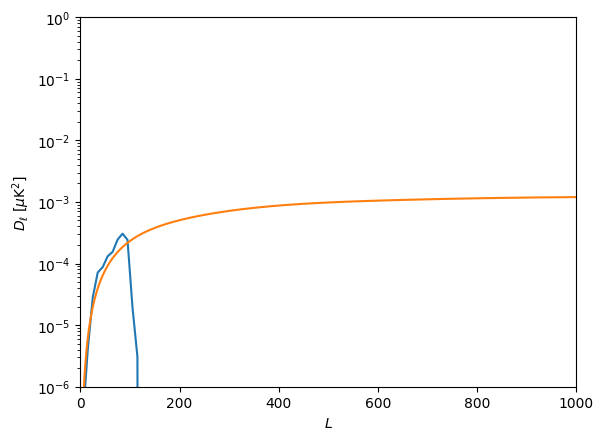

In [33]:
### Calculate binned 1d cross-power between reconstruction and input
ell_max = 1000
delta_ell = 10

##
Normalize_by_hand = 1e3

## make a cross-power spectrum
binned_ell, binned_spectrum = cm.calculate_2d_spectrum(ukappa_f, ikappa_f,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell,binned_spectrum* binned_ell * (binned_ell+1.)/2. / np.pi / Normalize_by_hand)
plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel('$L$')

## reload the thoery
ells,ucltt,lcltt,clkk = lm.get_theory()
DlKK = clkk*ells*(ells+1.)/2./np.pi

plt.semilogy(ells,DlKK)
plt.xlim(0,ell_max)
plt.ylim(1e-6,1)
plt.show()

### <font color='red'>Discussion Questions: </font>  

1. Adjust the nomarlization to make the curves line up.
1. How well does the shape of the two curves match up?
1. What explains the abrupt cuttoff in the cross-correlation at $\ell \sim 100$?
1. Adjust the filtering so that the reconstruiton extends to $\ell = 1000$. How well do these curves agree? You may have to adjust the normalization.  How do the maps look when you go up to this fine scale?
2. Play with the high and low $\ell$ limits for the reconstruction and discuss what happens. 

1. *Done*
1. *Pretty well*
1. *Filtering the reconstruction where ${k_{\ell}}_{max} = 100$.*
1. *See code below. I had to adjust the normalization to make the curves agree, but overall they agree very well. The reconstructed map looks very different than the input map, but the cross-power spectra agree. Cross kills the noise*
1. *See code below.*

<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\1139809048.py:26: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')


map mean: 1.210719347000122e-12 map rms: 466216.8246036845


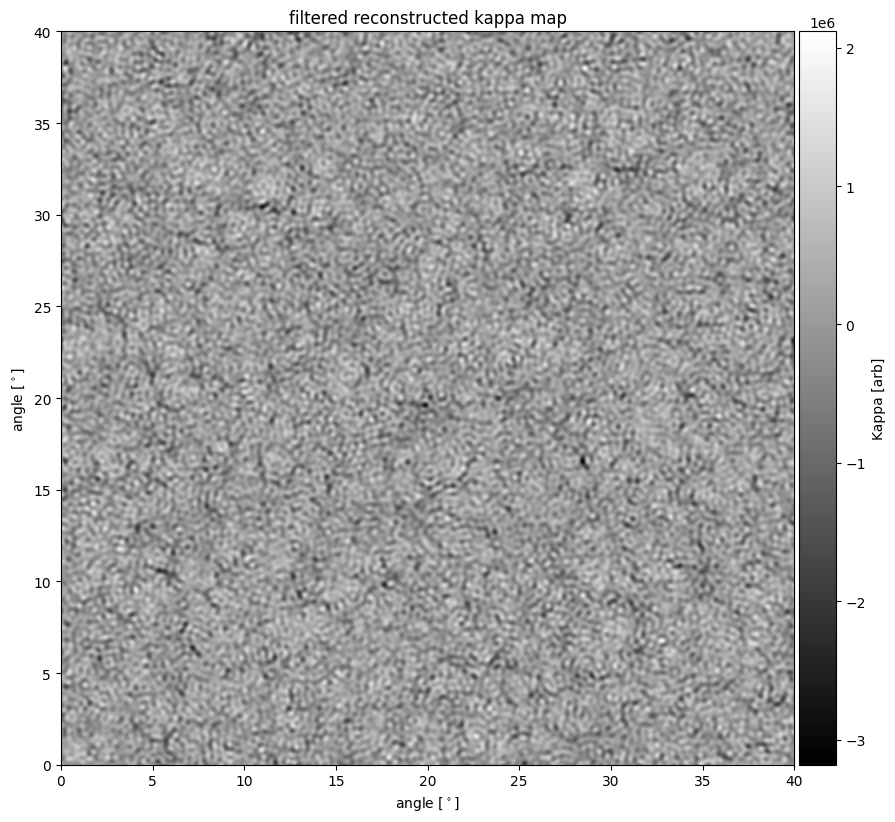

map mean: -7.632783294297952e-21 map rms: 0.04220990375110876


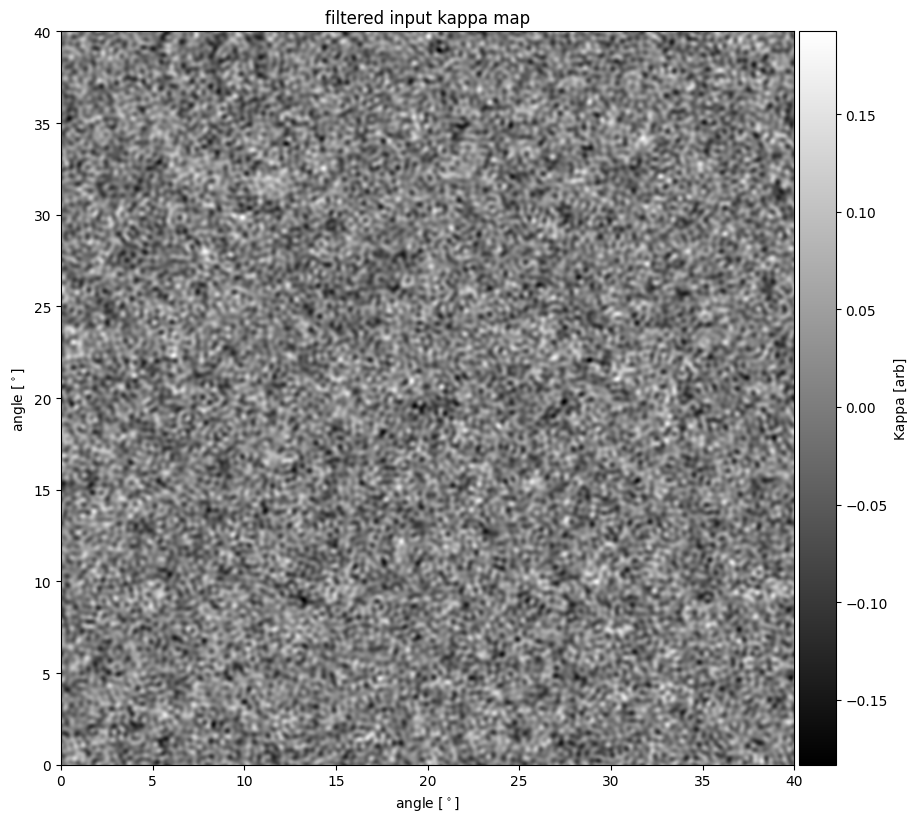

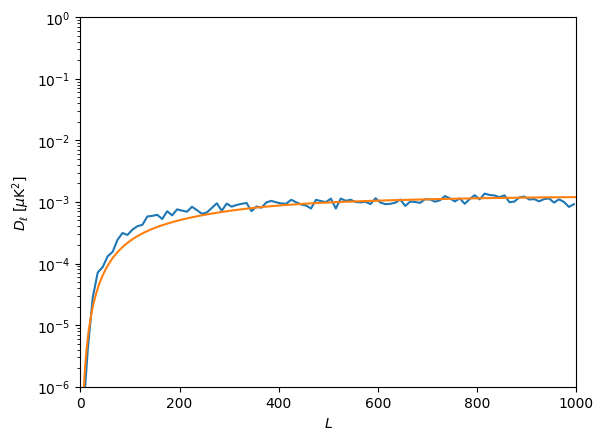

In [34]:
# 4
kellmin = 10
kellmax = 1000
ukappa_f = lm.filter_map(ukappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))
ikappa_f = lm.filter_map(kappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))

# Plot the filtered maps for comparison

plt.title("filtered reconstructed kappa map")
cm.Plot_CMB_Lensing_Map(ukappa_f,patch_deg_width,patch_deg_width)
             
plt.title("filtered input kappa map")
cm.Plot_CMB_Lensing_Map(ikappa_f,patch_deg_width,patch_deg_width)

### Calculate binned 1d cross-power between reconstruction and input
ell_max = 1000
delta_ell = 10

##
Normalize_by_hand = 1e3

## make a cross-power spectrum
binned_ell, binned_spectrum = cm.calculate_2d_spectrum(ukappa_f, ikappa_f,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell,binned_spectrum* binned_ell * (binned_ell+1.)/2. / np.pi / Normalize_by_hand)
plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel('$L$')

## reload the thoery
ells,ucltt,lcltt,clkk = lm.get_theory()
DlKK = clkk*ells*(ells+1.)/2./np.pi

plt.semilogy(ells,DlKK)
plt.xlim(0,ell_max)
plt.ylim(1e-6,1)
plt.show()

In [35]:
# 5


Unfortunately in real life, we do not know the true lensing signal to do this cross-correlation with an input and keep tuning it. However, we do understand the theory behind the quadratic estimator which provides an analytic expression for the response of a map to lensing.  This normalization is complicated, but possible to calculate analytically for the ideal case.  Small 10-20% corrections to this normalization can be estimated using well-understood simulations. 

We can compute cross-correlations between CMB lensing estimators and other tracers of large scale strucure like galaxy weak lensing, or the galaxy density estimated from visable or infrared photometric surveys.  However, these tracers include their own biases.   This provides measuremnts of a broad range of astrophysical parameters and cross-checks on cosmology and thus represents a major research effort for the field. We will discuss cross-correlations in an upcoming session.


## Auto spectra 
Harvesting the full information content of CMB lensing requries dealing with these biases, but enables use of the CMB lensing autocorrelation. In what follows we explore some of the issues that must be tackled to go beyond cross-correlation measurements.  

### <font color='red'>EXERCISE: </font> 
  Modify the code you wrote above to compute the auto-correlation.  Then answer the discusison questions below.  You should adjust the filtering so you can see modes up to $L = 1000$.

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\698349336.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')


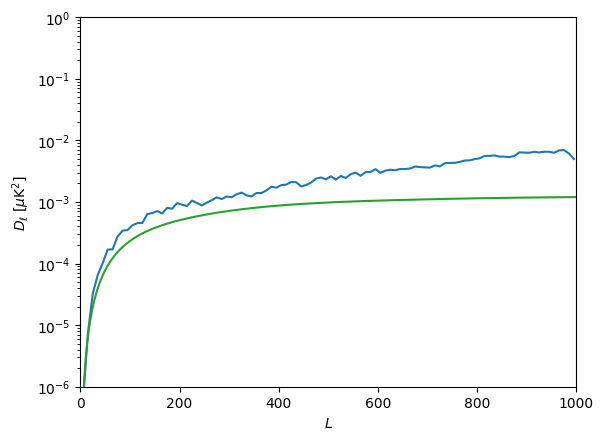

In [38]:
Normalize_by_hand = 1e5

## make a auto-power spectrum
binned_ell_u, binned_spectrum_u = cm.calculate_2d_spectrum(ukappa_f,ukappa_f,delta_ell,ell_max,pix_size,N)
binned_ell_i, binned_spectrum_i = cm.calculate_2d_spectrum(ikappa_f,ikappa_f,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell_u,binned_spectrum_u* binned_ell_u * (binned_ell_u+1.)/2. / np.pi / Normalize_by_hand**2, 
             label="Reconstructed")
plt.semilogy(binned_ell_i,binned_spectrum_i* binned_ell_i * (binned_ell_i+1.)/2. / np.pi / Normalize_by_hand**2, 
             label="Theory")
plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel('$L$')

## reload the thoery
ells,ucltt,lcltt,clkk = lm.get_theory()
DlKK = clkk*ells*(ells+1.)/2./np.pi

plt.semilogy(ells,DlKK)
plt.xlim(0,ell_max)
plt.ylim(1e-6,1)
plt.show()

### <font color='red'>Discussion Questions: </font> 

1. Is there bias in this estimator?  How could you differentiate noise vs bias?
1. What could affect the bias you see here?   Can you test and confirm this?


### Bias In Lensing Estimators 

Dealing with bias in estimates of the lensing power spectrum represents a large body of continuing research.   Major types of Biases include:

1.   $N^{(0)}$ bias is the expectation value of the lensing power spectrum estimator that would be obtained if the CMB were an unlensed Gaussian field that had the power spectrum of the observed lensed CMB. 
1. $N^{(1)}$ and $N^{(2)}$ are smaller biases that arise from higher-order considerations
2. Mean-field biases from statistical anisotropy due to a mask

These effects can be mitigated through careful choice of estimators (bias hardened estimators, and cross-estimators) or removed through Monte-Carlo simulations.  These biases can be large, so dealing with these represent the primary area of effort for producing cosmology from CMB lensing.  As the data go deeper, the required precisions for mitigating these effects must necessarily grow.   

### <font color='red'>EXERCISE: </font> 

Reproduce the existence of the mean-field bias by applying apodization to the edge of the map before reconstruction

map mean: -7.380731403827667e-12 map rms: 208923.25824250258


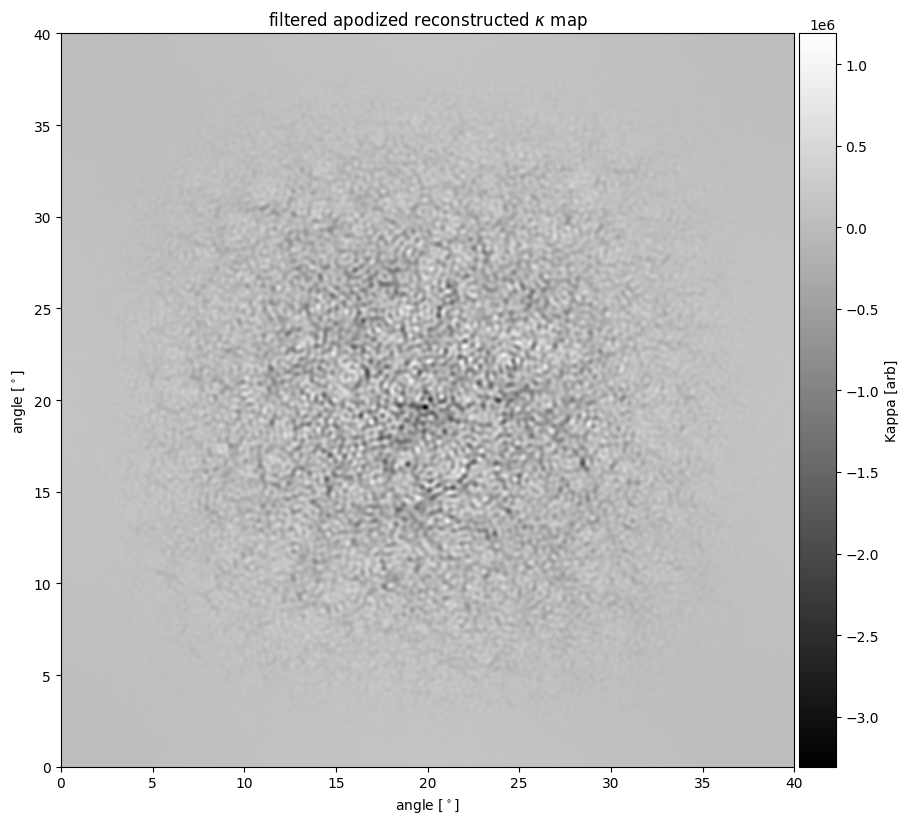

map mean: -7.632783294297952e-21 map rms: 0.04220990375110876


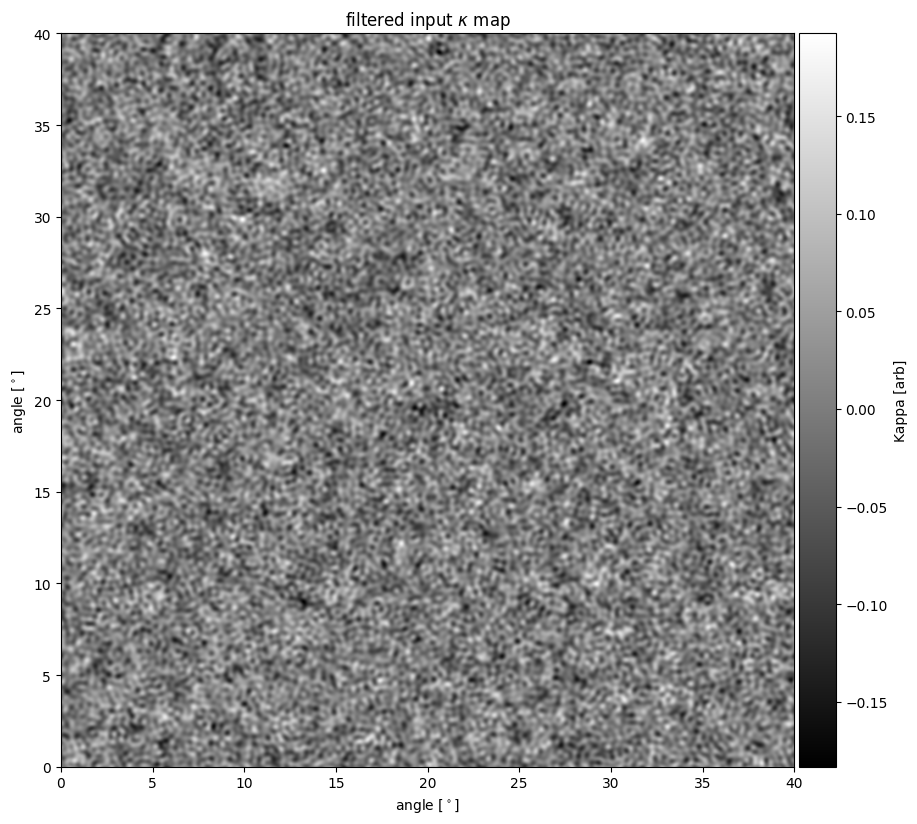

In [39]:
## make a window
window = cm.cosine_window(N)

tmap = lm.filter_map(observed, 1/kbeam2d) * window
### Next, we get the unnormalized reconstruction after choosing what multipoles to involve
ellmin = 100
ellmax = 3000
ukappa = qe_reconstruct(tmap,unlensed_cmb_power_2d,total_cmb_power_2d,ellmin,ellmax,modlmap,ly,lx)
# Calculating the normalization is a bit involved, so for now we focus on comparing
# the largest scales of the reconstruction with that of the input, where the normalization is
# expected to be somewhat constant

### Filter the reconstruction and the input kappa to the same ellrange (where the normalization
### is expected to be relatively white)
kellmin = 10
kellmax = 1000
ukappa_f = lm.filter_map(ukappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))
ikappa_f = lm.filter_map(kappa,lm.kmask(modlmap*0.+1.,modlmap,kellmin,kellmax))

# Plot the filtered maps for comparison

plt.title(r"filtered apodized reconstructed $\kappa$ map")
cm.Plot_CMB_Lensing_Map(ukappa_f,patch_deg_width,patch_deg_width)
             
plt.title(r"filtered input $\kappa$ map")
cm.Plot_CMB_Lensing_Map(ikappa_f,patch_deg_width,patch_deg_width)

<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\2360428345.py:12: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\2360428345.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


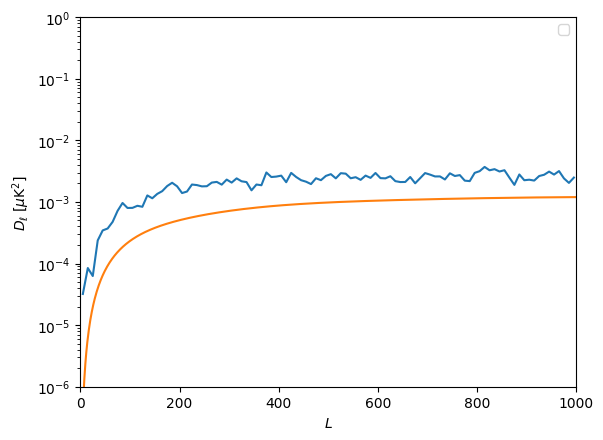

In [ ]:
### Calculate binned 1d cross-power between reconstruction and input
ell_max = 1000
delta_ell = 10

##
Normalize_by_hand = 0.99e2

## make a cross-power spectrum
binned_ell, binned_spectrum = cm.calculate_2d_spectrum(ukappa_f, ikappa_f,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell,binned_spectrum* binned_ell * (binned_ell+1.)/2. / np.pi / Normalize_by_hand)
plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel('$L$')

## reload the thoery
ells,ucltt,lcltt,clkk = lm.get_theory()
DlKK = clkk*ells*(ells+1.)/2./np.pi

plt.semilogy(ells,DlKK)
plt.xlim(0,ell_max)
plt.ylim(1e-6,1)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ricco\AppData\Local\Temp\ipykernel_28832\759068603.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')


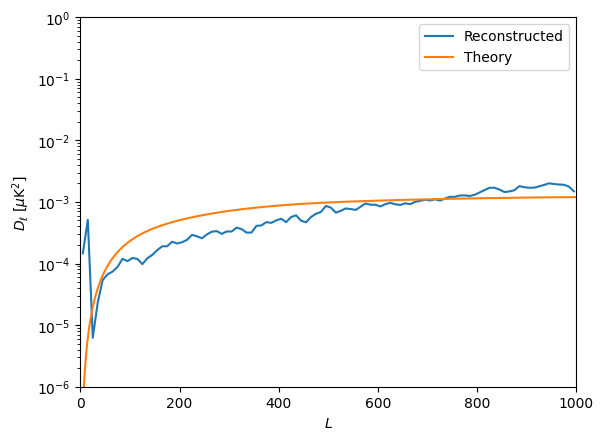

In [50]:
Normalize_by_hand = 5e9

## make an auto-power spectrum
binned_ell_u, binned_spectrum_u = cm.calculate_2d_spectrum(ukappa_f, ukappa_f,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell_u,binned_spectrum_u* binned_ell_u * (binned_ell_u+1.)/2. / np.pi / Normalize_by_hand, 
             label="Reconstructed")
plt.ylabel('$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel('$L$')

## reload the thoery
ells,ucltt,lcltt,clkk = lm.get_theory()
DlKK = clkk*ells*(ells+1.)/2./np.pi

plt.semilogy(ells,DlKK, label="Theory")
plt.legend();
plt.xlim(0,ell_max)
plt.ylim(1e-6,1)
plt.show()